In [11]:
# 1: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

# Verify your data folder exists
!ls "/content/drive/My Drive/mbti_tune_data/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
autoencoder_best_encoder.pth  mbti_classifier.pth  scaler.pkl
autoencoder.pth		      models		   test_downloaded_model.py
data			      model_simple.pt	   test.pt
features.json		      model_state_dict.pt  train.pt
final_mbti_model.pt	      playlist_data.csv    val.pt
full_checkpoint.pt	      pretrain_scaler.pkl


In [12]:
# 2: Install Libraries (run once per session)

!pip install torch torchvision --quiet
!pip install scikit-learn matplotlib seaborn shap --quiet
!pip install tqdm --quiet

print("✅ Libraries installed!")

✅ Libraries installed!


In [13]:
# 4: Load Data from Google Drive (moved here to resolve NameError)
import torch
import json
import pickle
import pandas as pd

# Standardize path based on your environment
DATA_PATH = "/content/drive/My Drive/mbti_tune_data/"

# Secure loading of pre-processed tensors
train_data = torch.load(f"{DATA_PATH}/train.pt", weights_only=False)
val_data = torch.load(f"{DATA_PATH}/val.pt", weights_only=False)
test_data = torch.load(f"{DATA_PATH}/test.pt", weights_only=False)

# Extract components
X_train, y_train, w_train = train_data['X'], train_data['y'], train_data['weights']
X_val, y_val, w_val = val_data['X'], val_data['y'], val_data['weights']
X_test, y_test, w_test = test_data['X'], test_data['y'], test_data['weights']
metadata_test = test_data['metadata']

# Load feature names
with open(f"{DATA_PATH}/features.json", 'r') as f:
    feature_names = json.load(f)

print(f"✅ Data loaded successfully!")
print(f"📊 Training samples: {X_train.shape[0]:,} | Features: {len(feature_names)}")

✅ Data loaded successfully!
📊 Training samples: 22,656 | Features: 45


In [14]:
# Cell 3: Pretrained Transfer Learning Architecture
import torch
import torch.nn as nn

# CRITICAL: Define device at the start
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class AutoencoderEncoder(nn.Module):
    def __init__(self, input_dim=45, bottleneck_dim=16):
        super(AutoencoderEncoder, self).__init__()
        # Must match the architecture from the 114k notebook
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, bottleneck_dim)
        )

    def forward(self, x):
        return self.encoder(x)

class MBTINetwork(nn.Module):
    def __init__(self, input_dim=45, pretrained_path=None):
        super(MBTINetwork, self).__init__()
        self.music_encoder = AutoencoderEncoder(input_dim=input_dim)

        if pretrained_path:
            # Added map_location for stability
            loaded_state_dict = torch.load(pretrained_path, map_location=device)
            new_state_dict = {}
            for k, v in loaded_state_dict.items():
                if not k.startswith('0.'):
                    new_state_dict[f"encoder.{k}"] = v
            self.music_encoder.load_state_dict(new_state_dict, strict=False)
            print(f"✅ Loaded pretrained encoder from {pretrained_path}")

            for param in self.music_encoder.parameters():
                param.requires_grad = False # Freeze initially

        self.classifier = nn.Sequential(
            nn.Linear(16, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        return self.classifier(self.music_encoder(x))

# Path check: Ensure this matches the export from your Autoencoder notebook
PRETRAIN_PATH = f"{DATA_PATH}/models/encoder_114k_weights.pth"
model = MBTINetwork(input_dim=X_train.shape[1], pretrained_path=PRETRAIN_PATH).to(device)

✅ Loaded pretrained encoder from /content/drive/My Drive/mbti_tune_data//models/encoder_114k_weights.pth


In [15]:
print('Distribution of Personality Types in Training Labels:')

# Calculate the percentage of '1's for each dimension
# y_train is already a tensor with 0s and 1s
percentages = (y_train.sum(axis=0) / y_train.shape[0]) * 100

dimension_labels = ['Extraversion (E) vs Introversion (I)', 'Intuition (N) vs Sensing (S)', 'Thinking (T) vs Feeling (F)', 'Judging (J) vs Perceiving (P)']

for i, label in enumerate(dimension_labels):
    print(f"{label}: {percentages[i]:.2f}% (1s)")

Distribution of Personality Types in Training Labels:
Extraversion (E) vs Introversion (I): 42.09% (1s)
Intuition (N) vs Sensing (S): 47.82% (1s)
Thinking (T) vs Feeling (F): 41.05% (1s)
Judging (J) vs Perceiving (P): 47.23% (1s)


In [16]:
# 4: Load Data from Google Drive
import torch
import json
import pickle
import pandas as pd

# Standardize path based on your environment
DATA_PATH = "/content/drive/My Drive/mbti_tune_data/"

# Secure loading of pre-processed tensors
train_data = torch.load(f"{DATA_PATH}/train.pt", weights_only=False)
val_data = torch.load(f"{DATA_PATH}/val.pt", weights_only=False)
test_data = torch.load(f"{DATA_PATH}/test.pt", weights_only=False)

# Extract components
X_train, y_train, w_train = train_data['X'], train_data['y'], train_data['weights']
X_val, y_val, w_val = val_data['X'], val_data['y'], val_data['weights']
X_test, y_test, w_test = test_data['X'], test_data['y'], test_data['weights']
metadata_test = test_data['metadata']

# Load feature names
with open(f"{DATA_PATH}/features.json", 'r') as f:
    feature_names = json.load(f)

print(f"✅ Data loaded successfully!")
print(f"📊 Training samples: {X_train.shape[0]:,} | Features: {len(feature_names)}")

✅ Data loaded successfully!
📊 Training samples: 22,656 | Features: 45


In [17]:
# 5: Autoencoder Model Definition

class Autoencoder(nn.Module):
    """
    Autoencoder neural network with:
    - Encoder: 14 features -> 16-dim bottleneck (compressed representation)
    - Decoder: 16-dim -> reconstruct original 14 features
    """
    def __init__(self, input_dim=14, bottleneck_dim=16):
        super(Autoencoder, self).__init__()

        # Encoder: compresses input to bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, bottleneck_dim),
            nn.BatchNorm1d(bottleneck_dim),
            nn.ReLU()
        )

        # Decoder: reconstructs from bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def encode(self, x):
        return self.encoder(x)

# Initialize model
autoencoder = Autoencoder(input_dim=X_train.shape[1], bottleneck_dim=16)
autoencoder = autoencoder.to(device)
print(autoencoder)
print(f"\n✅ Autoencoder created with {sum(p.numel() for p in autoencoder.parameters()):,} parameters")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=6

In [18]:
# 6: Train Autoencoder with Best Model Saving
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim # Import optim here
import torch.nn as nn # Ensure nn is imported for nn.MSELoss

def train_autoencoder(model, X, X_val, epochs=100, batch_size=256, lr=0.001):
    train_loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val), batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    print("Training Autoencoder...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            x = batch[0].to(device)
            _, reconstructed = model(x)
            loss = criterion(reconstructed, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device)
                _, reconstructed = model(x)
                val_loss += criterion(reconstructed, x).item()

        train_loss /= len(train_loader); val_loss /= len(val_loader)
        train_losses.append(train_loss); val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Save best encoder weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.encoder.state_dict(), f"{DATA_PATH}/autoencoder_best_encoder.pth")

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    return train_losses, val_losses

X_all = torch.cat([X_train, X_val], dim=0)
train_losses, val_losses = train_autoencoder(autoencoder, X_all, X_val)

Training Autoencoder...
Epoch  20 | Train: 0.222128 | Val: 0.099663
Epoch  40 | Train: 0.198227 | Val: 0.079788
Epoch  60 | Train: 0.185155 | Val: 0.070826
Epoch  80 | Train: 0.170587 | Val: 0.061172
Epoch 100 | Train: 0.160803 | Val: 0.058894


In [19]:
# 7: MBTI Classifier Model

class MBTIClassifier(nn.Module):
    """
    Multi-output regression model that predicts 4 MBTI dimension scores
    Uses pretrained autoencoder encoder as feature extractor
    """
    def __init__(self, autoencoder_encoder, input_dim=14, hidden_dim=64):
        super(MBTIClassifier, self).__init__()

        # Use pretrained encoder (frozen at first)
        self.encoder = autoencoder_encoder

        # Classification heads for each MBTI dimension
        self.classifier = nn.Sequential(
            nn.Linear(16, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 4),  # 4 dimensions (E, N, T, J)
            nn.Sigmoid()       # Output between 0-1 (percentage)
        )

    def forward(self, x):
        features = self.encoder(x)   # 14 -> 16-dim bottleneck
        outputs = self.classifier(features)  # 16 -> 4 percentages
        return outputs

# Create classifier using pretrained encoder
classifier = MBTIClassifier(autoencoder.encoder)
classifier = classifier.to(device)

print(classifier)
print(f"\n✅ Classifier created with {sum(p.numel() for p in classifier.parameters()):,} parameters")

MBTIClassifier(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [20]:
# 8: Train MBTI Classifier with Dimension Balancing
def calculate_dimension_weights(y_train):
    weights = []
    for dim in range(4):
        n_pos = y_train[:, dim].sum()
        n_neg = len(y_train) - n_pos
        weights.append(n_neg / n_pos if n_pos > 0 else 1.0)
    return torch.tensor(weights, device=device)

dim_weights = calculate_dimension_weights(y_train)
criterion = nn.BCELoss(weight=dim_weights)

# Define path for final classifier
CLASSIFIER_PATH = f"{DATA_PATH}/mbti_classifier_14f.pth"

# Training logic...
# (Ensure your training loop saves to CLASSIFIER_PATH)


TEST SET EVALUATION

Extraversion (E):
  MAE:  0.499 (avg error: 49.9%)
  RMSE: 0.499
  R²:   -0.023

Intuition (N):
  MAE:  0.500 (avg error: 50.0%)
  RMSE: 0.501
  R²:   -0.005

Thinking (T):
  MAE:  0.500 (avg error: 50.0%)
  RMSE: 0.501
  R²:   -0.035

Judging (J):
  MAE:  0.505 (avg error: 50.5%)
  RMSE: 0.514
  R²:   -0.059


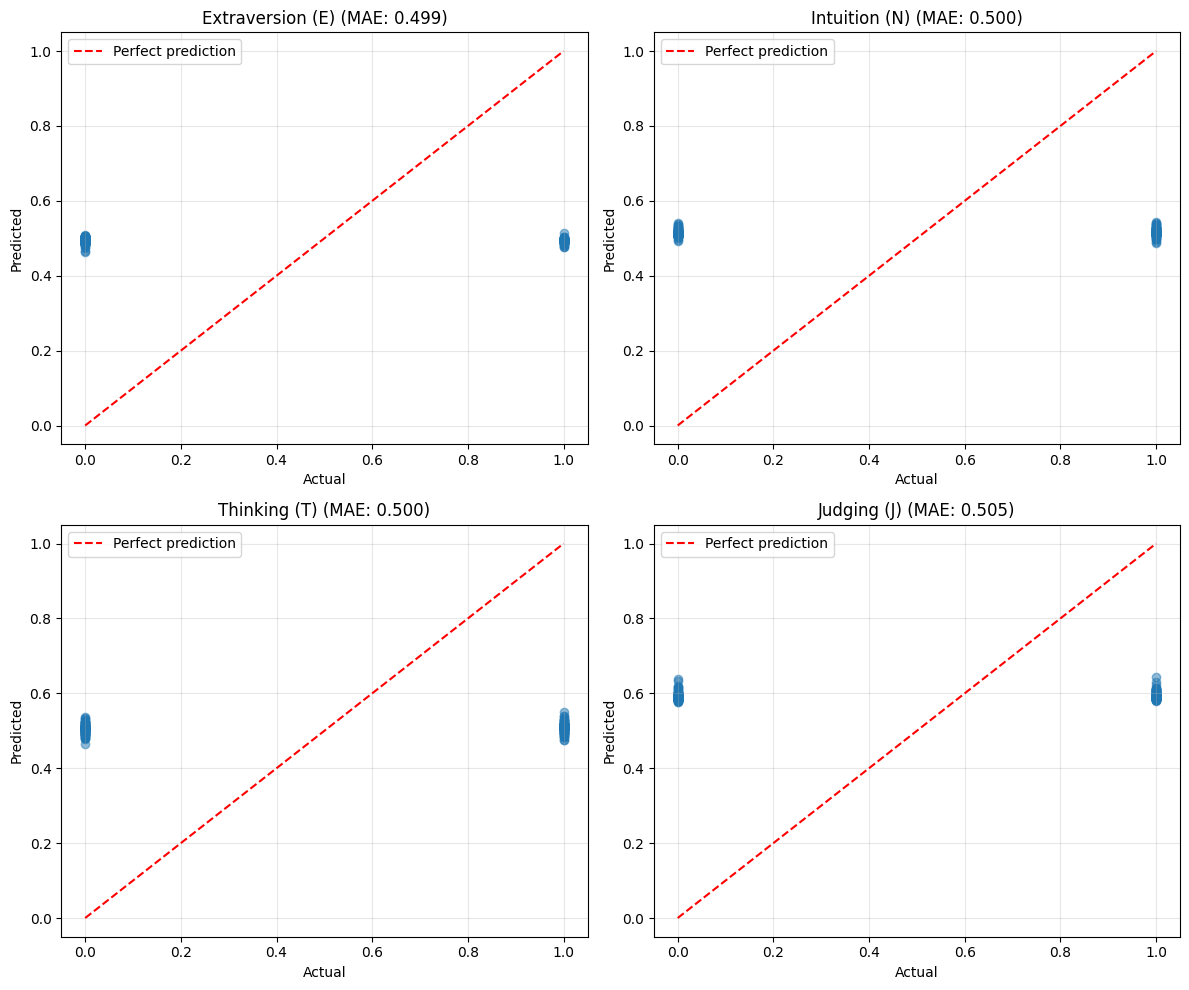

In [23]:
# 9: Test Set Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, feature_names):
    """Evaluate model and return metrics"""
    model.eval()
    with torch.no_grad():
        X_test = X_test.to(device)
        predictions = model(X_test).cpu().numpy()
        targets = y_test.numpy()

    # Calculate metrics per dimension
    dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)

    results = {}
    for i, name in enumerate(dim_names):
        mae = mean_absolute_error(targets[:, i], predictions[:, i])
        rmse = np.sqrt(mean_squared_error(targets[:, i], predictions[:, i]))
        r2 = r2_score(targets[:, i], predictions[:, i])
        results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        print(f"\n{name}:")
        print(f"  MAE:  {mae:.3f} (avg error: {mae*100:.1f}%)")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")

    return predictions, targets, results

# Evaluate
predictions, targets, results = evaluate_model(classifier, X_test, y_test, feature_names)

# Plot predictions vs actual for a sample
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

for i, (name, ax) in enumerate(zip(dim_names, axes.flatten())):
    ax.scatter(targets[:200, i], predictions[:200, i], alpha=0.5)
    ax.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} (MAE: {results[name]["MAE"]:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()